<a href="https://colab.research.google.com/github/antoshdyade/Blockchain-XAI-Transformer/blob/main/ThesisImpV3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install networkx tqdm

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv,GATConv,SAGEConv

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
BASE_PATH = "/content/drive/MyDrive/Elliptic"

FEATURE_FILE = f"{BASE_PATH}/elliptic_txs_features.csv"
CLASS_FILE   = f"{BASE_PATH}/elliptic_txs_classes.csv"
EDGE_FILE    = f"{BASE_PATH}/elliptic_txs_edgelist.csv"

In [ ]:
features = pd.read_csv(FEATURE_FILE, header=None)

classes = pd.read_csv(CLASS_FILE)

edges = pd.read_csv(EDGE_FILE)

print(features.shape)
print(classes.shape)
print(edges.shape)

(203769, 167)
(203769, 2)
(234355, 2)


In [ ]:
feature_cols = ["txId"] + [f"f{i}" for i in range(166)]

features.columns = feature_cols

features.head()

,txId,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f156,f157,f158,f159,f160,f161,f162,f163,f164,f165
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [ ]:
data = features.merge(classes,on="txId")

data.head()

,txId,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f157,f158,f159,f160,f161,f162,f163,f164,f165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


In [ ]:
data['class'] = data['class'].replace({
    '1':1,
    '2':0,
    'unknown':-1
})

data = data[data['class']!=-1]

print(data['class'].value_counts())

class
0    42019
1     4545
Name: count, dtype: int64


/tmp/ipykernel_26463/2789658036.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['class'] = data['class'].replace({


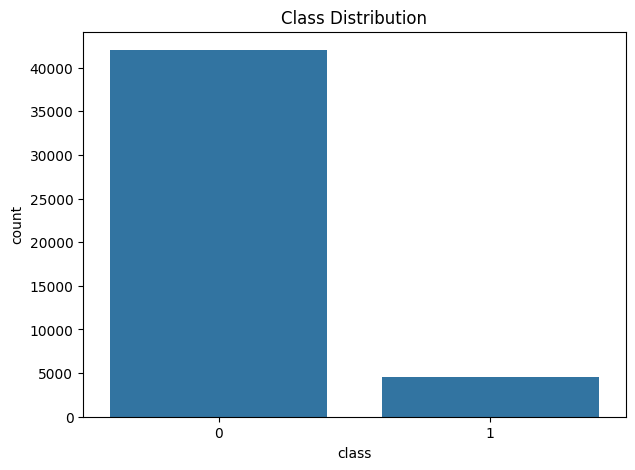

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x=data['class'])

plt.title("Class Distribution")
plt.show()

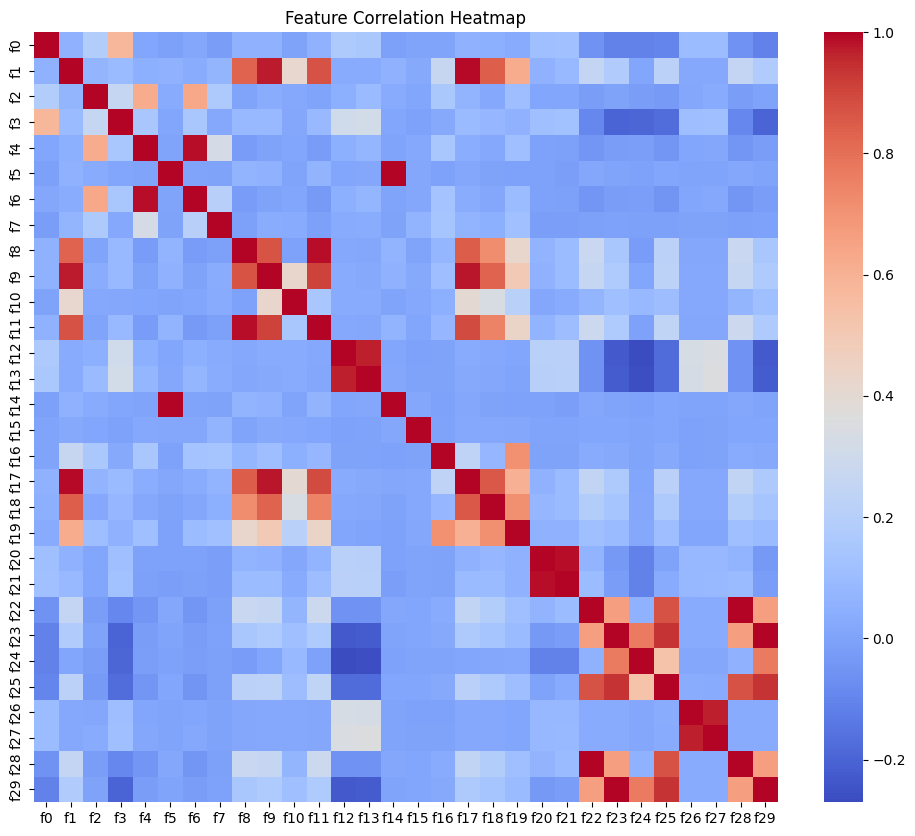

In [ ]:
corr = data.iloc[:,1:31].corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr,cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
corr_target = data.corr(numeric_only=True)['class'].abs()

top10 = corr_target.sort_values(
    ascending=False
).head(11)

top10

,class
class,1.000000
f53,0.261472
f89,0.227629
f55,0.227146
f90,0.221294
f142,0.191936
f150,0.187232
f91,0.185804
f52,0.171799
f154,0.152966


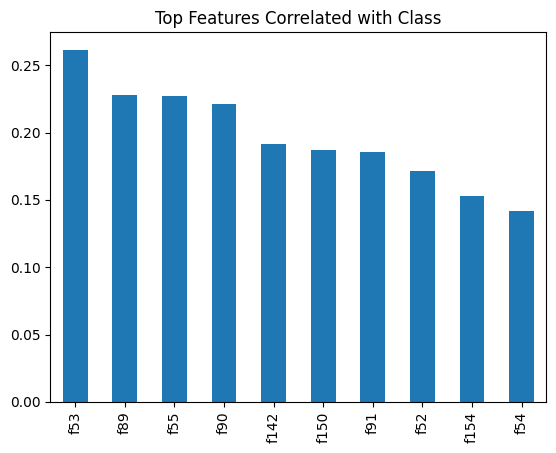

In [ ]:
top10[1:].plot(kind='bar')

plt.title("Top Features Correlated with Class")

plt.show()

In [ ]:
node_ids = data['txId'].values

X = data.drop(columns=['txId','class']).values

y = data['class'].values

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
node_map = {
    node:i
    for i,node in enumerate(node_ids)
}

In [ ]:
edge_index=[]

for _,row in tqdm(edges.iterrows(),total=len(edges)):

    s=row['txId1']
    d=row['txId2']

    if s in node_map and d in node_map:

        edge_index.append([
            node_map[s],
            node_map[d]
        ])

edge_index=np.array(edge_index)

100%|██████████| 234355/234355 [00:05<00:00, 39281.57it/s]


In [ ]:
x=torch.tensor(X,dtype=torch.float)

y=torch.tensor(y,dtype=torch.long)

edge_index=torch.tensor(
    edge_index.T,
    dtype=torch.long
)

graph_data = Data(
    x=x,
    edge_index=edge_index,
    y=y
)

graph_data

Data(x=[46564, 166], edge_index=[2, 36624], y=[46564])

In [ ]:
idx=np.arange(len(y))

train_idx,test_idx=train_test_split(
    idx,
    test_size=0.2,
    stratify=y,
    random_state=42
)

train_mask=torch.zeros(len(y),dtype=torch.bool)
test_mask=torch.zeros(len(y),dtype=torch.bool)

train_mask[train_idx]=True
test_mask[test_idx]=True

graph_data.train_mask=train_mask
graph_data.test_mask=test_mask

In [ ]:
import numpy as np
import pandas as pd

results=[]

def evaluate_model(
        model,
        data,
        model_name):

    model.eval()

    with torch.no_grad():

        logits=model(data.x,data.edge_index)

        probs=F.softmax(logits,dim=1)

        pred=probs.argmax(dim=1)

    y_true=data.y[data.test_mask].cpu().numpy()

    y_pred=pred[data.test_mask].cpu().numpy()

    y_prob=probs[data.test_mask][:,1].cpu().numpy()

    acc=accuracy_score(y_true,y_pred)

    prec=precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    rec=recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1=f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc=roc_auc_score(
        y_true,
        y_prob
    )

    pr=average_precision_score(
        y_true,
        y_prob
    )

    results.append([
        model_name,
        acc,
        prec,
        rec,
        f1,
        roc,
        pr
    ])

    print("\n",model_name)

    print(classification_report(
        y_true,
        y_pred
    ))

    return y_true,y_pred,y_prob

In [ ]:
class GCN(torch.nn.Module):

    def __init__(self,
                 in_channels,
                 hidden=128):

        super().__init__()

        self.conv1=GCNConv(
            in_channels,
            hidden
        )

        self.conv2=GCNConv(
            hidden,
            2
        )

    def forward(
        self,
        x,
        edge_index
    ):

        x=self.conv1(
            x,
            edge_index
        )

        x=F.relu(x)

        x=F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x=self.conv2(
            x,
            edge_index
        )

        return x

In [ ]:
def train_gnn(
        model,
        data,
        epochs=100,
        lr=0.001):

    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4
    )

    criterion=torch.nn.CrossEntropyLoss()

    losses=[]

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        out=model(
            data.x,
            data.edge_index
        )

        loss=criterion(
            out[data.train_mask],
            data.y[data.train_mask]
        )

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

        if epoch%10==0:

            print(
                f"Epoch {epoch} Loss {loss.item():.4f}"
            )

    return losses

In [ ]:
gcn=GCN(
    graph_data.num_features
)

gcn_losses=train_gnn(
    gcn,
    graph_data,
    epochs=100
)

Epoch 0 Loss 0.8359
Epoch 10 Loss 0.2690
Epoch 20 Loss 0.2152
Epoch 30 Loss 0.1994
Epoch 40 Loss 0.1866
Epoch 50 Loss 0.1781
Epoch 60 Loss 0.1693
Epoch 70 Loss 0.1651
Epoch 80 Loss 0.1593
Epoch 90 Loss 0.1543


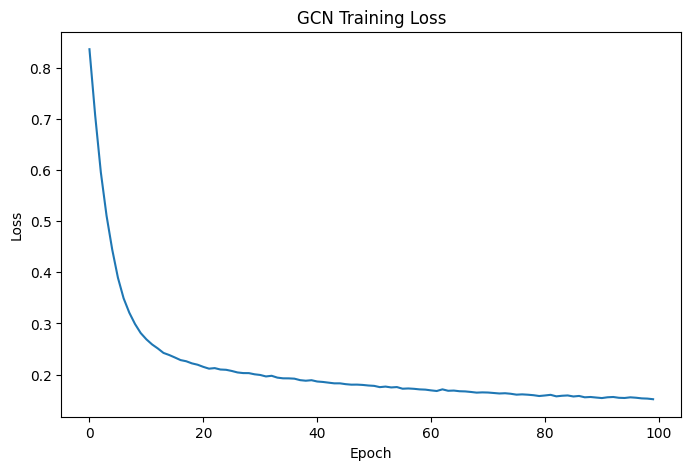

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(gcn_losses)

plt.title(
    "GCN Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [ ]:
gcn_true,\
gcn_pred,\
gcn_prob = evaluate_model(
    gcn,
    graph_data,
    "GCN"
)


 GCN
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      8404
           1       0.89      0.67      0.77       909

    accuracy                           0.96      9313
   macro avg       0.93      0.83      0.87      9313
weighted avg       0.96      0.96      0.96      9313



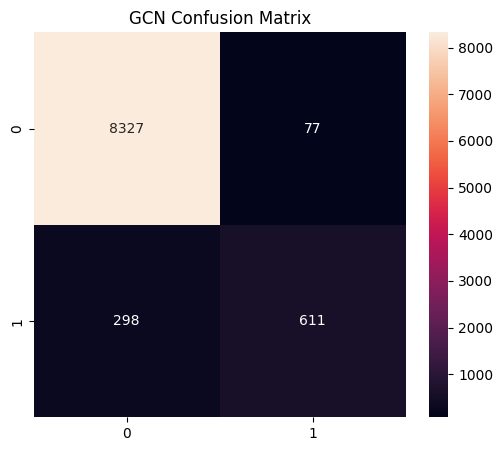

In [ ]:
cm=confusion_matrix(
    gcn_true,
    gcn_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "GCN Confusion Matrix"
)

plt.show()

In [ ]:
class GAT(torch.nn.Module):

    def __init__(
            self,
            in_channels):

        super().__init__()

        self.gat1=GATConv(
            in_channels,
            64,
            heads=4
        )

        self.gat2=GATConv(
            64*4,
            2,
            heads=1
        )

    def forward(
            self,
            x,
            edge_index):

        x=self.gat1(
            x,
            edge_index
        )

        x=F.elu(x)

        x=F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x=self.gat2(
            x,
            edge_index
        )

        return x

In [ ]:
gat=GAT(
    graph_data.num_features
)

gat_losses=train_gnn(
    gat,
    graph_data,
    epochs=100
)

Epoch 0 Loss 0.9004
Epoch 10 Loss 0.3326
Epoch 20 Loss 0.2314
Epoch 30 Loss 0.2022
Epoch 40 Loss 0.1830
Epoch 50 Loss 0.1760
Epoch 60 Loss 0.1678
Epoch 70 Loss 0.1631
Epoch 80 Loss 0.1558
Epoch 90 Loss 0.1518


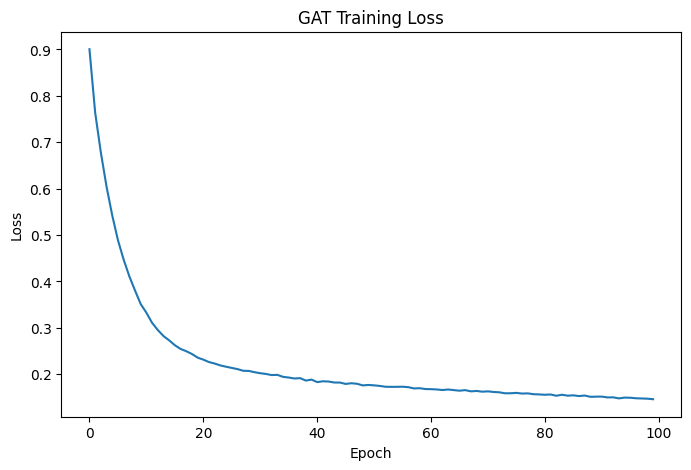

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(gat_losses)

plt.title(
    "GAT Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [ ]:
gat_true,\
gat_pred,\
gat_prob=evaluate_model(
    gat,
    graph_data,
    "GAT"
)


 GAT
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      8404
           1       0.87      0.67      0.76       909

    accuracy                           0.96      9313
   macro avg       0.92      0.83      0.87      9313
weighted avg       0.96      0.96      0.96      9313



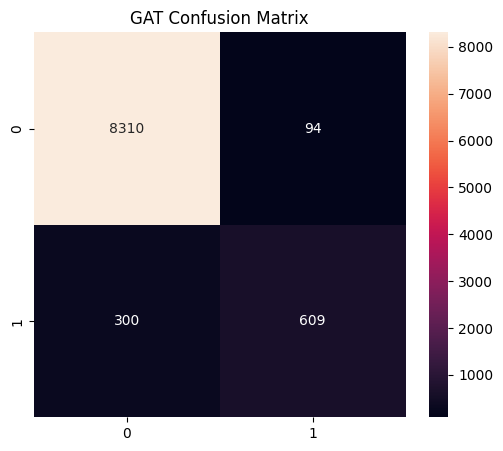

In [ ]:
cm=confusion_matrix(
    gat_true,
    gat_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "GAT Confusion Matrix"
)

plt.show()

In [ ]:
class GraphSAGE(torch.nn.Module):

    def __init__(
            self,
            in_channels):

        super().__init__()

        self.sage1=SAGEConv(
            in_channels,
            128
        )

        self.sage2=SAGEConv(
            128,
            2
        )

    def forward(
            self,
            x,
            edge_index):

        x=self.sage1(
            x,
            edge_index
        )

        x=F.relu(x)

        x=F.dropout(
            x,
            p=0.3,
            training=self.training
        )

        x=self.sage2(
            x,
            edge_index
        )

        return x

In [ ]:
sage=GraphSAGE(
    graph_data.num_features
)

sage_losses=train_gnn(
    sage,
    graph_data,
    epochs=100
)

Epoch 0 Loss 0.5609
Epoch 10 Loss 0.2797
Epoch 20 Loss 0.2172
Epoch 30 Loss 0.1852
Epoch 40 Loss 0.1645
Epoch 50 Loss 0.1499
Epoch 60 Loss 0.1395
Epoch 70 Loss 0.1304
Epoch 80 Loss 0.1228
Epoch 90 Loss 0.1172


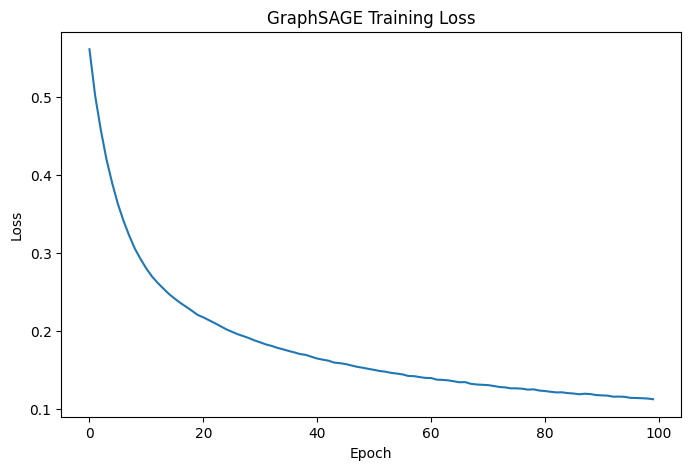

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(sage_losses)

plt.title(
    "GraphSAGE Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [ ]:
sage_true,\
sage_pred,\
sage_prob=evaluate_model(
    sage,
    graph_data,
    "GraphSAGE"
)


 GraphSAGE
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      8404
           1       0.91      0.73      0.81       909

    accuracy                           0.97      9313
   macro avg       0.94      0.86      0.90      9313
weighted avg       0.97      0.97      0.96      9313



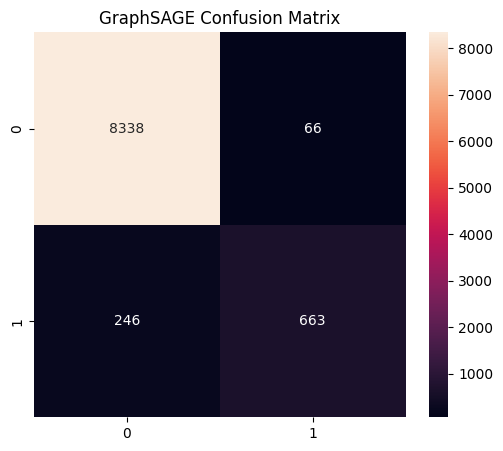

In [ ]:
cm=confusion_matrix(
    sage_true,
    sage_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "GraphSAGE Confusion Matrix"
)

plt.show()

In [ ]:
gnn_outputs={

    "GCN":{
        "true":gcn_true,
        "pred":gcn_pred,
        "prob":gcn_prob
    },

    "GAT":{
        "true":gat_true,
        "pred":gat_pred,
        "prob":gat_prob
    },

    "GraphSAGE":{
        "true":sage_true,
        "pred":sage_pred,
        "prob":sage_prob
    }
}

In [ ]:
gnn_results=pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
)

gnn_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,GCN,0.959734,0.888081,0.672167,0.765185,0.946364,0.819289
1,GAT,0.957694,0.866287,0.669967,0.755583,0.949446,0.808293
2,GraphSAGE,0.966498,0.909465,0.729373,0.809524,0.963243,0.867814


In [ ]:
gnn_results.to_csv(
    f"{BASE_PATH}/gnn_results.csv",
    index=False
)

print("Saved")

Saved


In [ ]:
X_train = X[train_idx]
X_test  = X[test_idx]

y_train = y[train_idx].cpu().numpy()
y_test  = y[test_idx].cpu().numpy()

print(X_train.shape)
print(X_test.shape)

(37251, 166)
(9313, 166)


In [ ]:
lr = LogisticRegression(
    max_iter=500,
    n_jobs=-1
)

lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=500, n_jobs=-1)

In [ ]:
lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test,lr_pred)

prec = precision_score(y_test,lr_pred)

rec = recall_score(y_test,lr_pred)

f1 = f1_score(y_test,lr_pred)

roc = roc_auc_score(y_test,lr_prob)

pr = average_precision_score(
    y_test,
    lr_prob
)

results.append([
    "Logistic Regression",
    acc,
    prec,
    rec,
    f1,
    roc,
    pr
])

print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      8404
           1       0.83      0.72      0.77       909

    accuracy                           0.96      9313
   macro avg       0.90      0.85      0.87      9313
weighted avg       0.96      0.96      0.96      9313



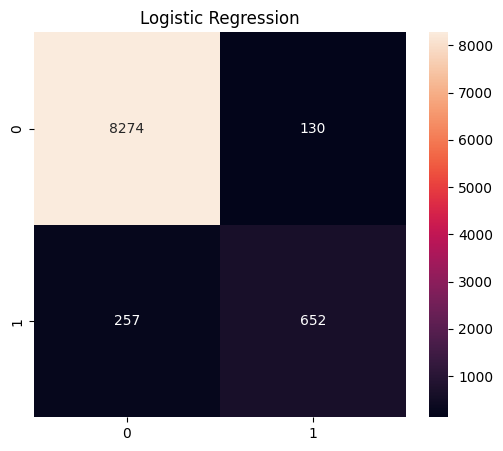

In [ ]:
cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Logistic Regression"
)

plt.show()

In [ ]:
iso = IsolationForest(
    contamination=0.02,
    random_state=42,
    n_estimators=200
)

iso.fit(X_train)

IsolationForest(contamination=0.02, n_estimators=200, random_state=42)

In [ ]:
iso_pred = iso.predict(X_test)

iso_pred = np.where(
    iso_pred==-1,
    1,
    0
)

iso_score = -iso.score_samples(
    X_test
)

In [ ]:
acc = accuracy_score(
    y_test,
    iso_pred
)

prec = precision_score(
    y_test,
    iso_pred,
    zero_division=0
)

rec = recall_score(
    y_test,
    iso_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    iso_pred,
    zero_division=0
)

roc = roc_auc_score(
    y_test,
    iso_score
)

pr = average_precision_score(
    y_test,
    iso_score
)

results.append([
    "Isolation Forest",
    acc,
    prec,
    rec,
    f1,
    roc,
    pr
])

print(classification_report(
    y_test,
    iso_pred
))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      8404
           1       0.00      0.00      0.00       909

    accuracy                           0.88      9313
   macro avg       0.45      0.49      0.47      9313
weighted avg       0.81      0.88      0.85      9313



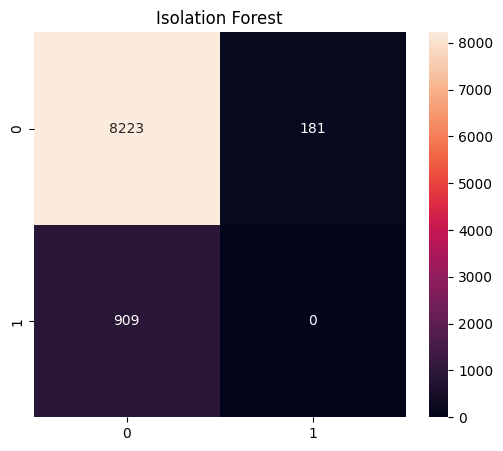

In [ ]:
cm = confusion_matrix(
    y_test,
    iso_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Isolation Forest"
)

plt.show()

In [ ]:
input_dim = X_train.shape[1]

autoencoder = Sequential([

    Dense(
        128,
        activation='relu',
        input_shape=(input_dim,)
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        input_dim,
        activation='linear'
    )
])

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.7919 - val_loss: 0.5307
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5038 - val_loss: 0.3781
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3878 - val_loss: 0.3027
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3205 - val_loss: 0.2574
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2685 - val_loss: 0.2433
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2416 - val_loss: 0.2121
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2264 - val_loss: 0.1922
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2027 - val_loss: 0.1904
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1997 - val_loss: 0.1748
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1812 - val_loss: 0.1643
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1682 - val_loss: 0.1641
Epoch 12/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1629 - val_l

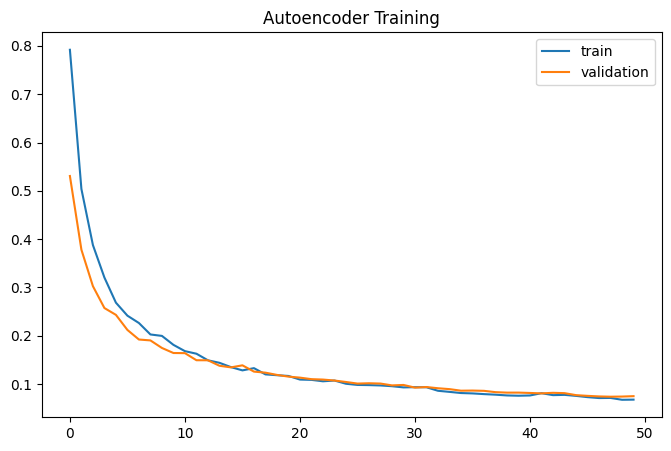

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='validation'
)

plt.legend()

plt.title(
    "Autoencoder Training"
)

plt.show()

In [ ]:
recon = autoencoder.predict(
    X_test
)

mse = np.mean(
    np.square(
        X_test-recon
    ),
    axis=1
)

292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
threshold = np.percentile(
    mse,
    95
)

ae_pred = (
    mse > threshold
).astype(int)

In [ ]:
acc = accuracy_score(
    y_test,
    ae_pred
)

prec = precision_score(
    y_test,
    ae_pred,
    zero_division=0
)

rec = recall_score(
    y_test,
    ae_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    ae_pred,
    zero_division=0
)

roc = roc_auc_score(
    y_test,
    mse
)

pr = average_precision_score(
    y_test,
    mse
)

results.append([
    "Autoencoder",
    acc,
    prec,
    rec,
    f1,
    roc,
    pr
])

print(classification_report(
    y_test,
    ae_pred
))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92      8404
           1       0.01      0.01      0.01       909

    accuracy                           0.85      9313
   macro avg       0.46      0.48      0.46      9313
weighted avg       0.81      0.85      0.83      9313



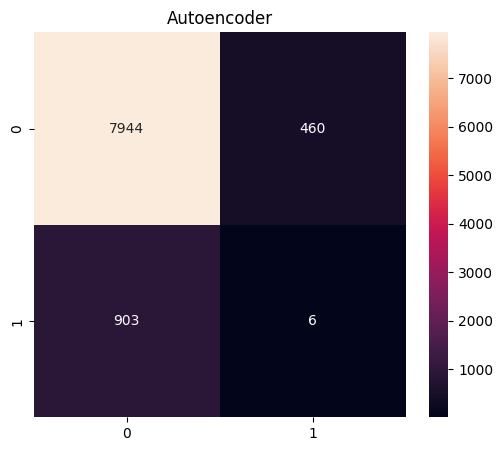

In [ ]:
cm = confusion_matrix(
    y_test,
    ae_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Autoencoder"
)

plt.show()

In [ ]:
final_results = pd.DataFrame(

    results,

    columns=[

        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
)

final_results.sort_values(
    by="F1",
    ascending=False,
    inplace=True
)

final_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,GraphSAGE,0.966498,0.909465,0.729373,0.809524,0.963243,0.867814
3,Logistic Regression,0.958445,0.833760,0.717272,0.771141,0.964126,0.792861
0,GCN,0.959734,0.888081,0.672167,0.765185,0.946364,0.819289
1,GAT,0.957694,0.866287,0.669967,0.755583,0.949446,0.808293
5,Autoencoder,0.853645,0.012876,0.006601,0.008727,0.186476,0.056582
4,Isolation Forest,0.882959,0.000000,0.000000,0.000000,0.102338,0.052351


In [ ]:
final_results.to_csv(

    f"{BASE_PATH}/Final_Model_Results.csv",

    index=False
)

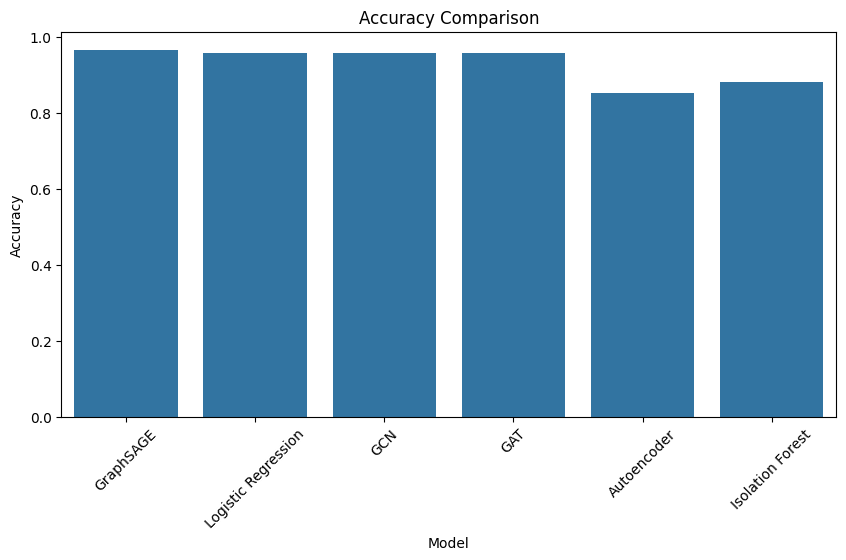

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Model",

    y="Accuracy",

    data=final_results
)

plt.xticks(rotation=45)

plt.title(
    "Accuracy Comparison"
)

plt.show()

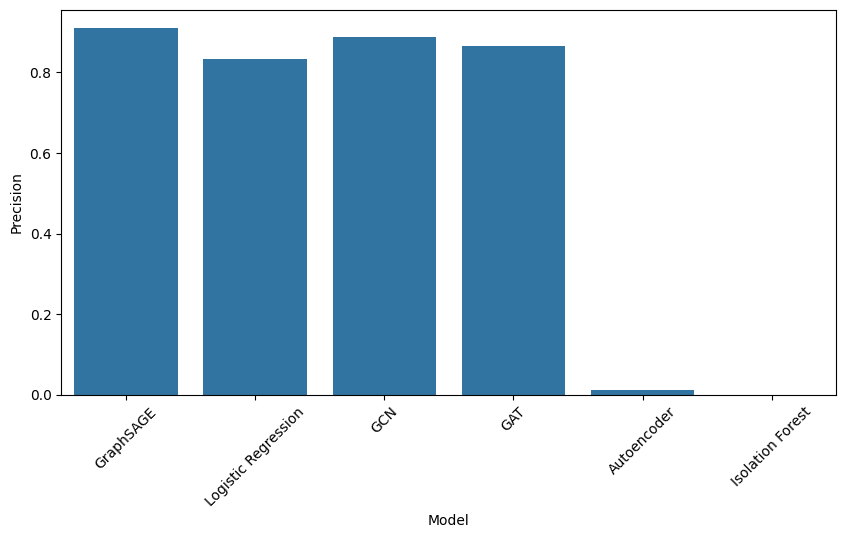

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Model",

    y="Precision",

    data=final_results
)

plt.xticks(rotation=45)

plt.show()

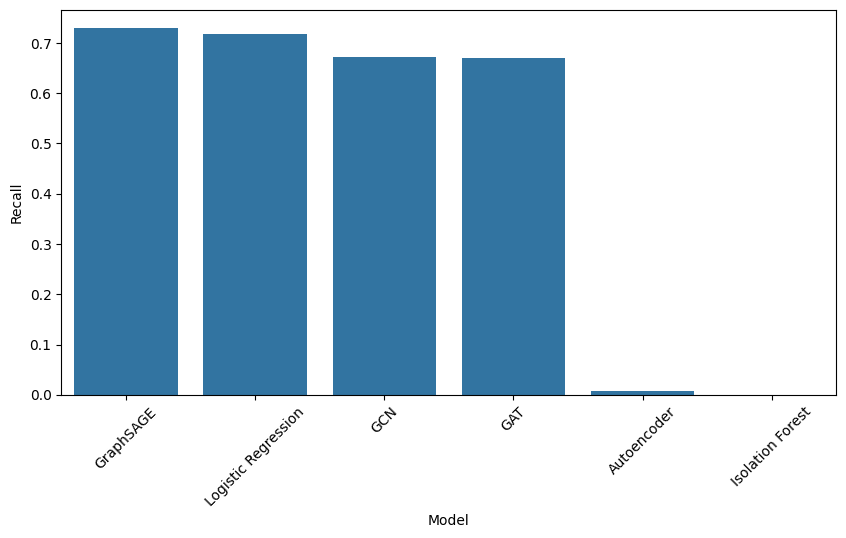

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Model",

    y="Recall",

    data=final_results
)

plt.xticks(rotation=45)

plt.show()

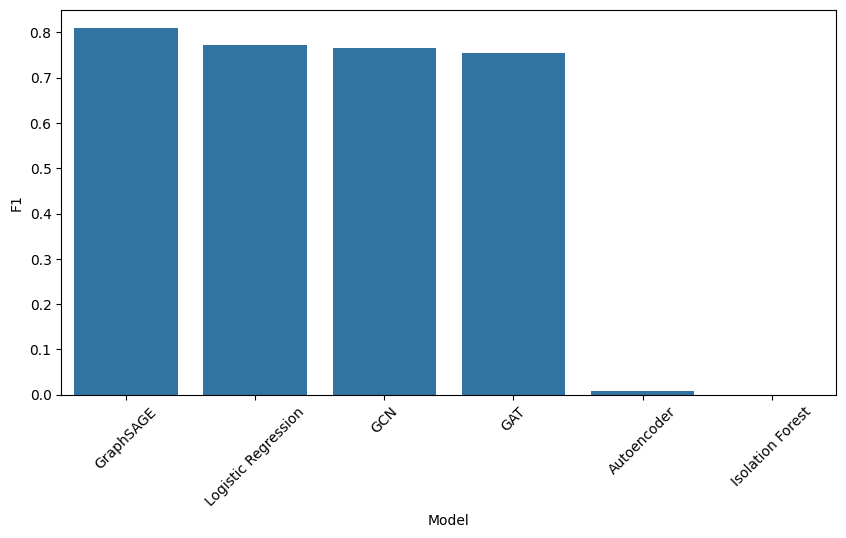

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(

    x="Model",

    y="F1",

    data=final_results
)

plt.xticks(rotation=45)

plt.show()

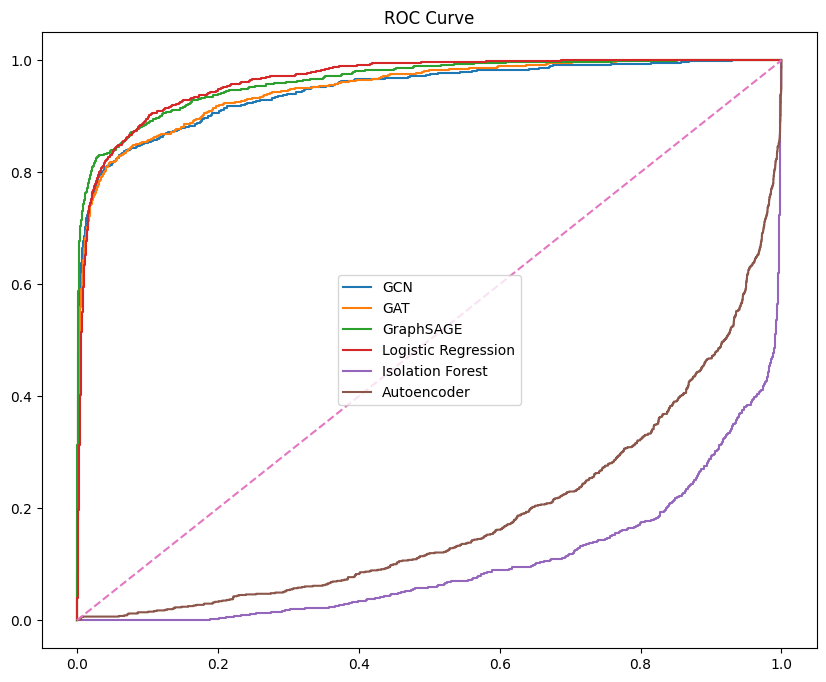

In [ ]:
plt.figure(figsize=(10,8))

for name,obj in gnn_outputs.items():

    fpr,tpr,_ = roc_curve(
        obj["true"],
        obj["prob"]
    )

    plt.plot(
        fpr,
        tpr,
        label=name
    )

fpr,tpr,_ = roc_curve(
    y_test,
    lr_prob
)

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression"
)

fpr,tpr,_ = roc_curve(
    y_test,
    iso_score
)

plt.plot(
    fpr,
    tpr,
    label="Isolation Forest"
)

fpr,tpr,_ = roc_curve(
    y_test,
    mse
)

plt.plot(
    fpr,
    tpr,
    label="Autoencoder"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.legend()

plt.title("ROC Curve")

plt.show()

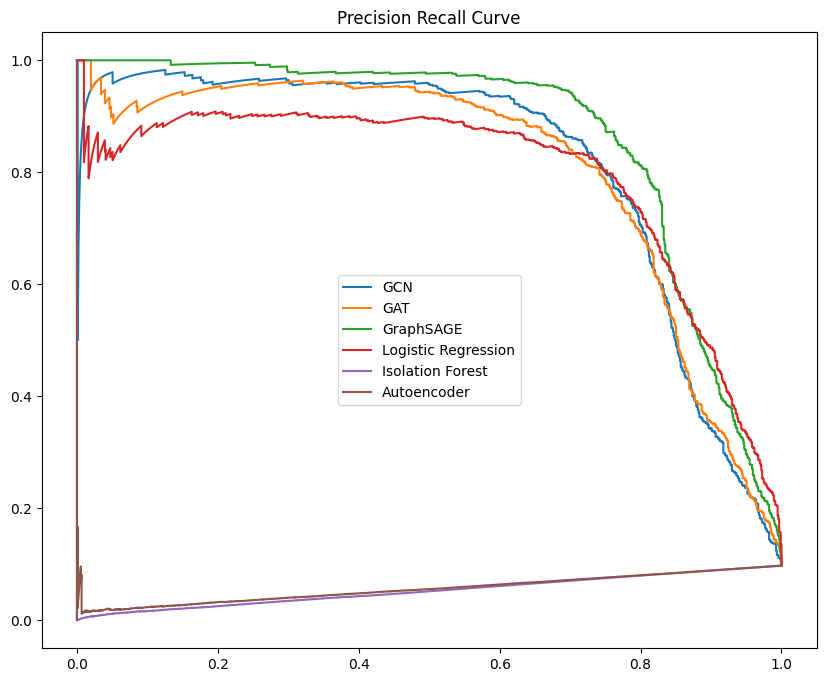

In [ ]:
plt.figure(figsize=(10,8))

for name,obj in gnn_outputs.items():

    p,r,_ = precision_recall_curve(
        obj["true"],
        obj["prob"]
    )

    plt.plot(
        r,
        p,
        label=name
    )

p,r,_ = precision_recall_curve(
    y_test,
    lr_prob
)

plt.plot(
    r,
    p,
    label="Logistic Regression"
)

p,r,_ = precision_recall_curve(
    y_test,
    iso_score
)

plt.plot(
    r,
    p,
    label="Isolation Forest"
)

p,r,_ = precision_recall_curve(
    y_test,
    mse
)

plt.plot(
    r,
    p,
    label="Autoencoder"
)

plt.legend()

plt.title(
    "Precision Recall Curve"
)

plt.show()

In [ ]:
ranking = final_results.sort_values(
    by="F1",
    ascending=False
)

ranking

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,GraphSAGE,0.966498,0.909465,0.729373,0.809524,0.963243,0.867814
3,Logistic Regression,0.958445,0.833760,0.717272,0.771141,0.964126,0.792861
0,GCN,0.959734,0.888081,0.672167,0.765185,0.946364,0.819289
1,GAT,0.957694,0.866287,0.669967,0.755583,0.949446,0.808293
5,Autoencoder,0.853645,0.012876,0.006601,0.008727,0.186476,0.056582
4,Isolation Forest,0.882959,0.000000,0.000000,0.000000,0.102338,0.052351


In [ ]:
best_model = ranking.iloc[0]

print(
    best_model
)

Model        GraphSAGE
Accuracy      0.966498
Precision     0.909465
Recall        0.729373
F1            0.809524
ROC_AUC       0.963243
PR_AUC        0.867814
Name: 2, dtype: object


In [ ]:
with pd.ExcelWriter(

    f"{BASE_PATH}/Dissertation_Results.xlsx"

) as writer:

    final_results.to_excel(
        writer,
        sheet_name="Model Results",
        index=False
    )

print("Export Complete")

Export Complete


In [ ]:
chapter4_table = final_results.copy()

chapter4_table.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,GraphSAGE,0.9665,0.9095,0.7294,0.8095,0.9632,0.8678
3,Logistic Regression,0.9584,0.8338,0.7173,0.7711,0.9641,0.7929
0,GCN,0.9597,0.8881,0.6722,0.7652,0.9464,0.8193
1,GAT,0.9577,0.8663,0.6700,0.7556,0.9494,0.8083
5,Autoencoder,0.8536,0.0129,0.0066,0.0087,0.1865,0.0566
4,Isolation Forest,0.8830,0.0000,0.0000,0.0000,0.1023,0.0524


In [ ]:
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install node2vec

In [ ]:
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn.neural_network import MLPClassifier

In [ ]:
rf = RandomForestClassifier(

    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=20, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [ ]:
acc = accuracy_score(y_test,rf_pred)

prec = precision_score(y_test,rf_pred)

rec = recall_score(y_test,rf_pred)

f1 = f1_score(y_test,rf_pred)

roc = roc_auc_score(
    y_test,
    rf_prob
)

pr = average_precision_score(
    y_test,
    rf_prob
)

results.append([
    "Random Forest",
    acc,
    prec,
    rec,
    f1,
    roc,
    pr
])

In [ ]:
xgb = XGBClassifier(

    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

In [ ]:
results.append([

    "XGBoost",

    accuracy_score(y_test,xgb_pred),

    precision_score(y_test,xgb_pred),

    recall_score(y_test,xgb_pred),

    f1_score(y_test,xgb_pred),

    roc_auc_score(y_test,xgb_prob),

    average_precision_score(
        y_test,
        xgb_prob
    )
])

In [ ]:
lgbm = LGBMClassifier(

    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(
    X_train,
    y_train
)

In [ ]:
lgb_pred = lgbm.predict(X_test)

lgb_prob = lgbm.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
results.append([

    "LightGBM",

    accuracy_score(y_test,lgb_pred),

    precision_score(y_test,lgb_pred),

    recall_score(y_test,lgb_pred),

    f1_score(y_test,lgb_pred),

    roc_auc_score(y_test,lgb_prob),

    average_precision_score(
        y_test,
        lgb_prob
    )
])

In [ ]:
y_train_np = y_train

y_test_np = y_test

In [ ]:
cat = CatBoostClassifier(

    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='F1',
    verbose=100,
    random_seed=42
)

cat.fit(
    X_train,
    y_train_np
)

In [ ]:
cat_pred = cat.predict(X_test)

cat_prob = cat.predict_proba(X_test)[:,1]

In [ ]:
results.append([

    "CatBoost",

    accuracy_score(y_test,cat_pred),

    precision_score(y_test,cat_pred),

    recall_score(y_test,cat_pred),

    f1_score(y_test,cat_pred),

    roc_auc_score(y_test,cat_prob),

    average_precision_score(
        y_test,
        cat_prob
    )
])

In [ ]:
mlp = MLPClassifier(

    hidden_layer_sizes=(256,128,64),

    max_iter=100,

    random_state=42
)

mlp.fit(
    X_train,
    y_train
)

In [ ]:
mlp_pred = mlp.predict(X_test)

mlp_prob = mlp.predict_proba(X_test)[:,1]

In [ ]:
results.append([

    "MLP",

    accuracy_score(y_test,mlp_pred),

    precision_score(y_test,mlp_pred),

    recall_score(y_test,mlp_pred),

    f1_score(y_test,mlp_pred),

    roc_auc_score(y_test,mlp_prob),

    average_precision_score(
        y_test,
        mlp_prob
    )
])

In [ ]:
import networkx as nx

G = nx.Graph()

G.add_edges_from(
    edge_index.T.numpy()
)

In [90]:
from node2vec import Node2Vec

node2vec = Node2Vec(

    G,

    dimensions=64,

    walk_length=10,

    num_walks=20,

    workers=4
)

model = node2vec.fit(
    window=10,
    min_count=1
)

Computing transition probabilities:   0%|          | 0/35874 [00:00<?, ?it/s]

In [95]:
eembeddings = []

dim = model.vector_size

for i in range(len(node_ids)):

    key = str(i)

    if key in model.wv:

        embeddings.append(
            model.wv[key]
        )

    else:

        embeddings.append(
            np.zeros(dim)
        )

embeddings = np.array(embeddings)

print(embeddings.shape)

(46570, 64)


In [96]:
X_train_emb = embeddings[train_idx]

X_test_emb = embeddings[test_idx]

In [97]:
rf_embed = RandomForestClassifier(

    n_estimators=500,

    random_state=42
)

rf_embed.fit(
    X_train_emb,
    y_train
)

RandomForestClassifier(n_estimators=500, random_state=42)

In [98]:
pred = rf_embed.predict(
    X_test_emb
)

prob = rf_embed.predict_proba(
    X_test_emb
)[:,1]

In [99]:
results.append([

    "Node2Vec+RF",

    accuracy_score(y_test,pred),

    precision_score(y_test,pred),

    recall_score(y_test,pred),

    f1_score(y_test,pred),

    roc_auc_score(y_test,prob),

    average_precision_score(
        y_test,
        prob
    )
])

In [100]:
xgb_embed = XGBClassifier(

    n_estimators=500,

    max_depth=8,

    eval_metric='logloss'
)

xgb_embed.fit(
    X_train_emb,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [101]:
pred = xgb_embed.predict(
    X_test_emb
)

prob = xgb_embed.predict_proba(
    X_test_emb
)[:,1]

In [102]:
results.append([

    "Node2Vec+XGBoost",

    accuracy_score(y_test,pred),

    precision_score(y_test,pred),

    recall_score(y_test,pred),

    f1_score(y_test,pred),

    roc_auc_score(y_test,prob),

    average_precision_score(
        y_test,
        prob
    )
])

In [103]:
comparison = pd.DataFrame(

    results,

    columns=[

        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ]
)

comparison.sort_values(

    by="F1",

    ascending=False,

    inplace=True
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
8,LightGBM,0.992591,0.996454,0.927393,0.960684,0.998495,0.991292
7,XGBoost,0.991947,0.996429,0.920792,0.957118,0.998319,0.989600
9,CatBoost,0.991517,0.996411,0.916392,0.954728,0.997774,0.988016
6,Random Forest,0.987866,0.998747,0.876788,0.933802,0.996331,0.981221
10,MLP,0.981639,0.930070,0.877888,0.903226,0.984807,0.942702
2,GraphSAGE,0.966498,0.909465,0.729373,0.809524,0.963243,0.867814
3,Logistic Regression,0.958445,0.833760,0.717272,0.771141,0.964126,0.792861
0,GCN,0.959734,0.888081,0.672167,0.765185,0.946364,0.819289
1,GAT,0.957694,0.866287,0.669967,0.755583,0.949446,0.808293
12,Node2Vec+XGBoost,0.891335,0.255924,0.059406,0.096429,0.635598,0.148262


In [104]:
comparison.to_csv(

    f"{BASE_PATH}/Complete_Model_Comparison.csv",

    index=False
)